*----------Califronia Pouse Price Prediction Project-------------*
                    Multiple Linear Regression

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import joblib

#========================================
# LOAD DATASET
#========================================

In [5]:
df = pd.read_csv("data.csv")

print("First 5 Rows")
print(df.head())

First 5 Rows
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41          880           129.0   
1    -122.22     37.86                  21         7099          1106.0   
2    -122.24     37.85                  52         1467           190.0   
3    -122.25     37.85                  52         1274           235.0   
4    -122.25     37.85                  52         1627           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0         322         126         8.3252              452600        NEAR BAY  
1        2401        1138         8.3014              358500        NEAR BAY  
2         496         177         7.2574              352100        NEAR BAY  
3         558         219         5.6431              341300        NEAR BAY  
4         565         259         3.8462              342200        NEAR BAY  


In [6]:
print("\nDataset Information")
print(df.info())


Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(4), int64(5), str(1)
memory usage: 1.6 MB
None


In [7]:
print("\nStatistical Summary")
print(df.describe())


Statistical Summary
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900   

#======================================
# DATA CLEANING
#======================================

In [8]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [9]:
print("\nDuplicate Values:", df.duplicated().sum())


Duplicate Values: 0


In [10]:
print("\nRemoving missing values...")

df.dropna(inplace=True)


Removing missing values...


In [11]:
print("\nRemaining Missing Values")
print(df.isnull().sum())


Remaining Missing Values
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


# ==============================================
# EXPLORATORY DATA ANALYSIS
# ==============================================

In [12]:
numerical_columns = [

    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "median_house_value"

]

# =============================================
# PAIRPLOT
# =============================================

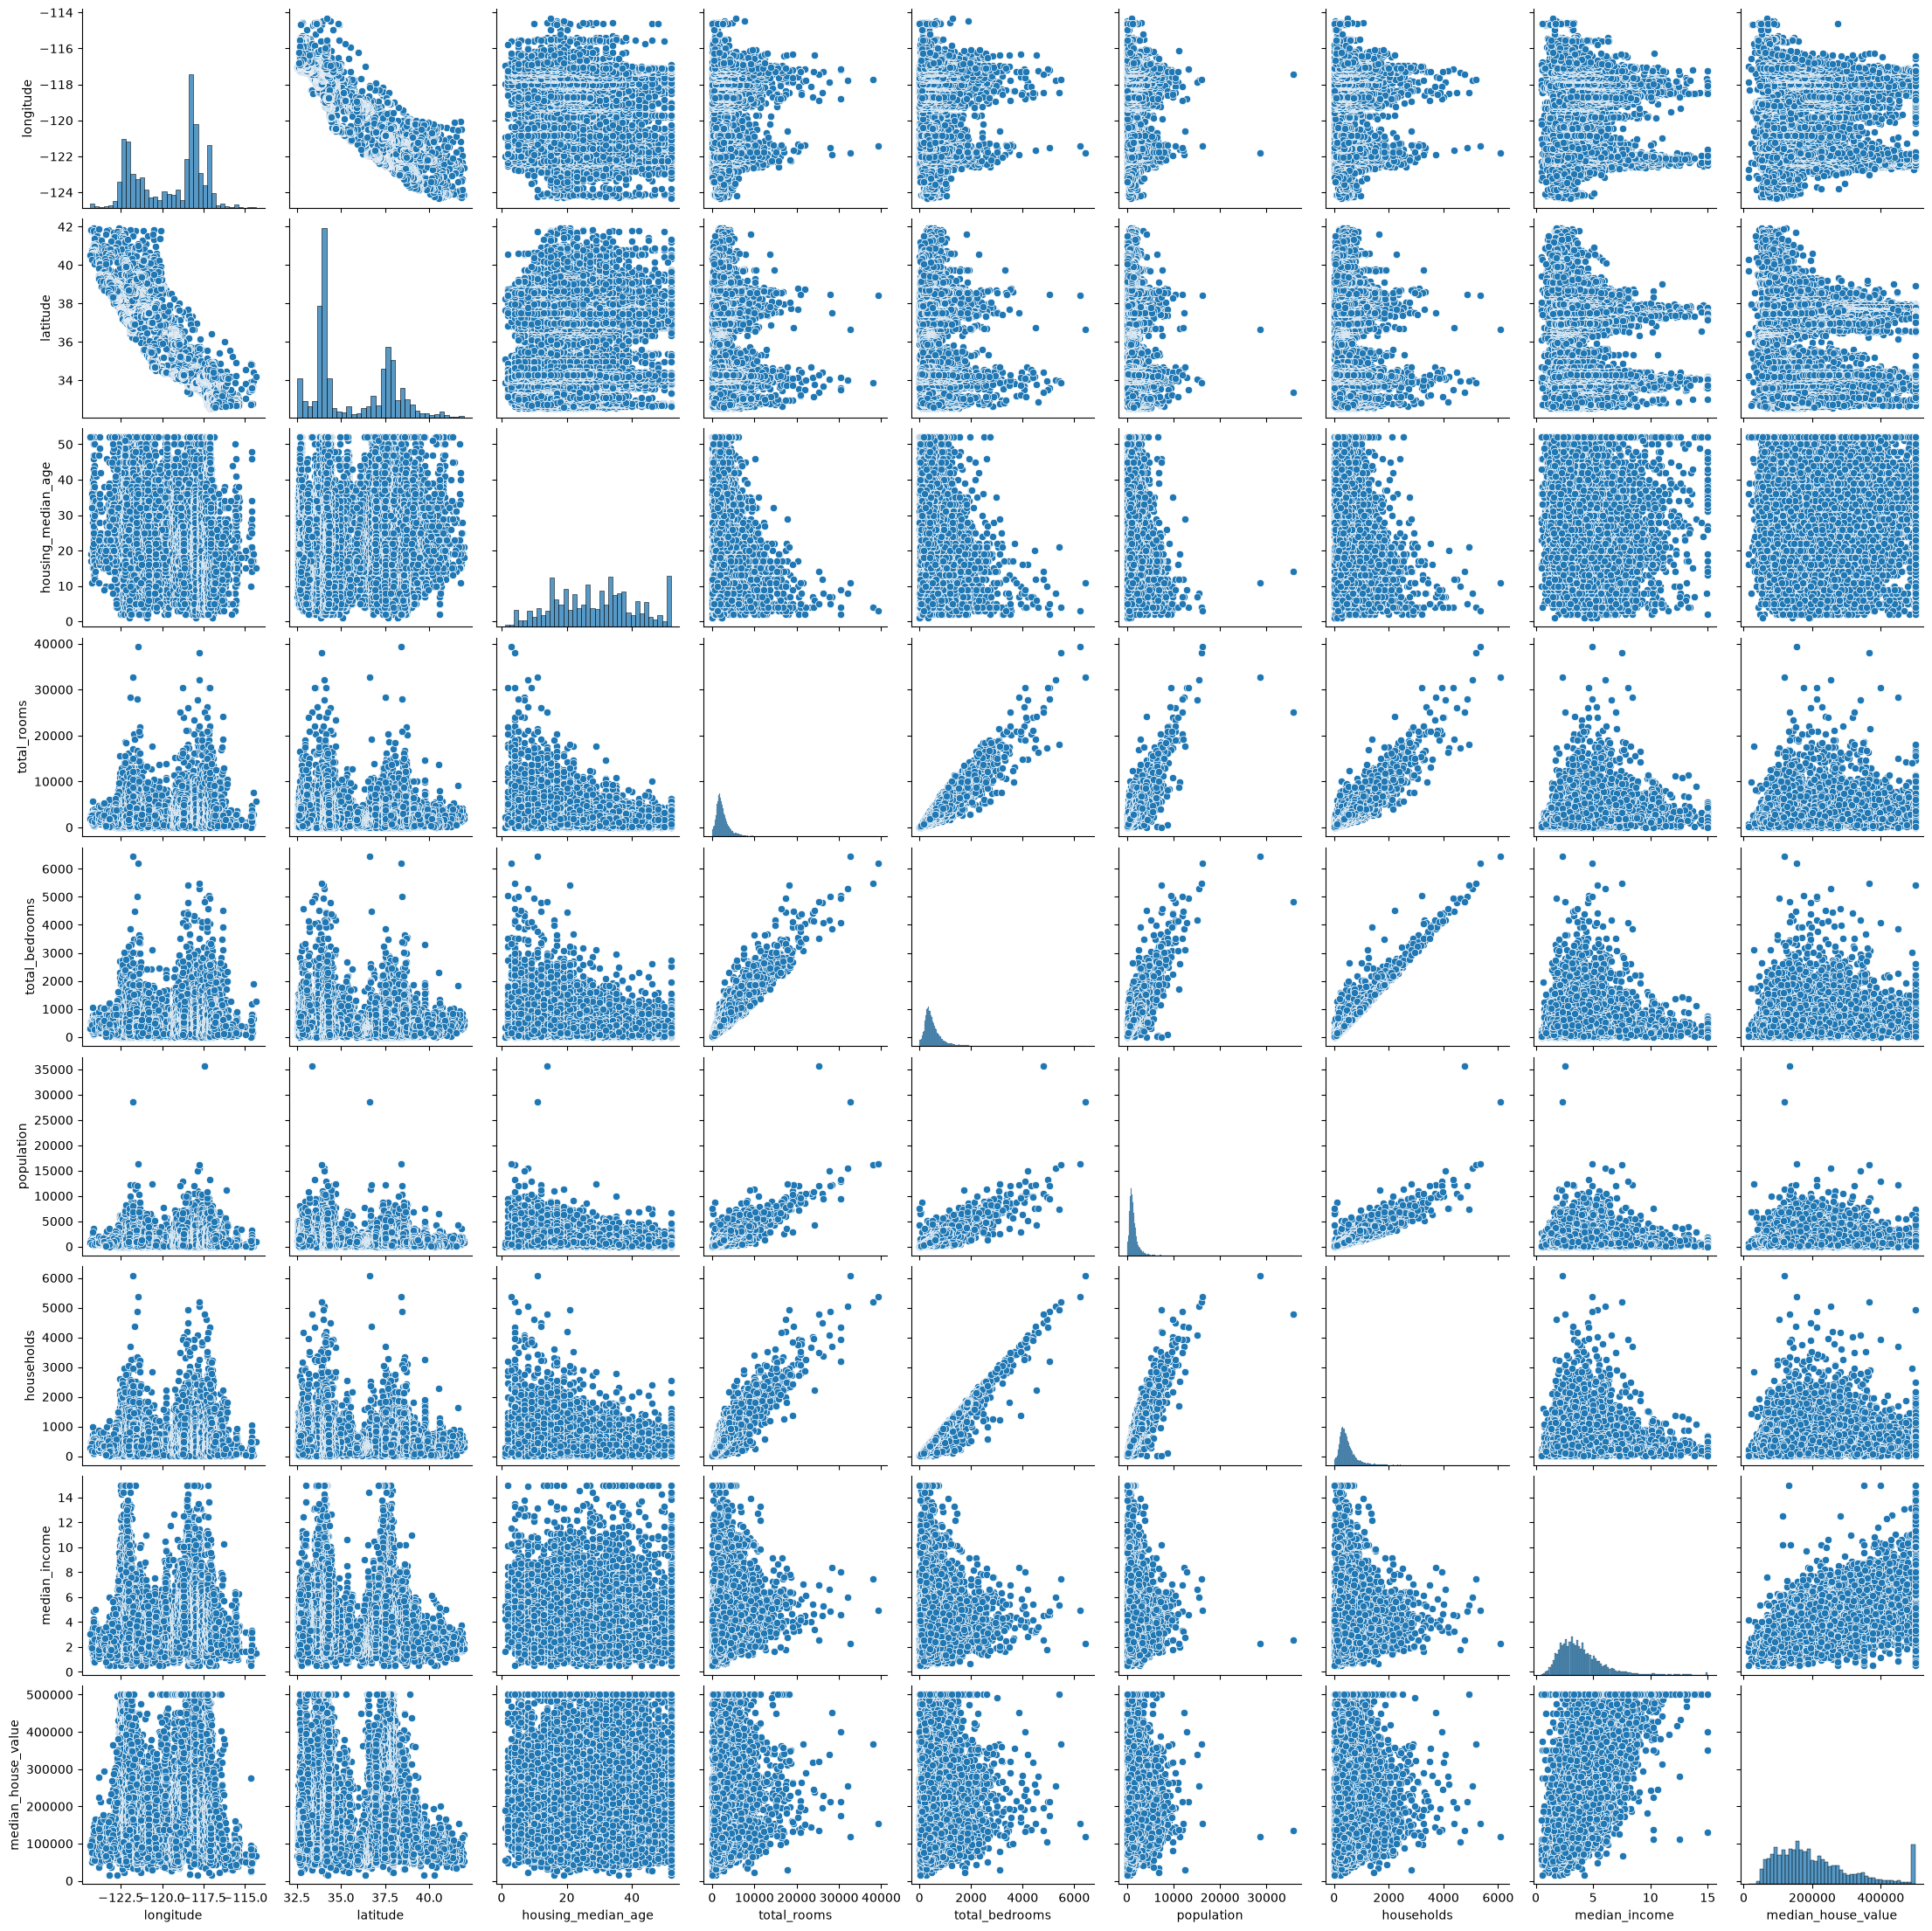

In [13]:
sns.pairplot(df[numerical_columns])
plt.show()

# ======================================
# CORRELATION MATRIX
# ======================================

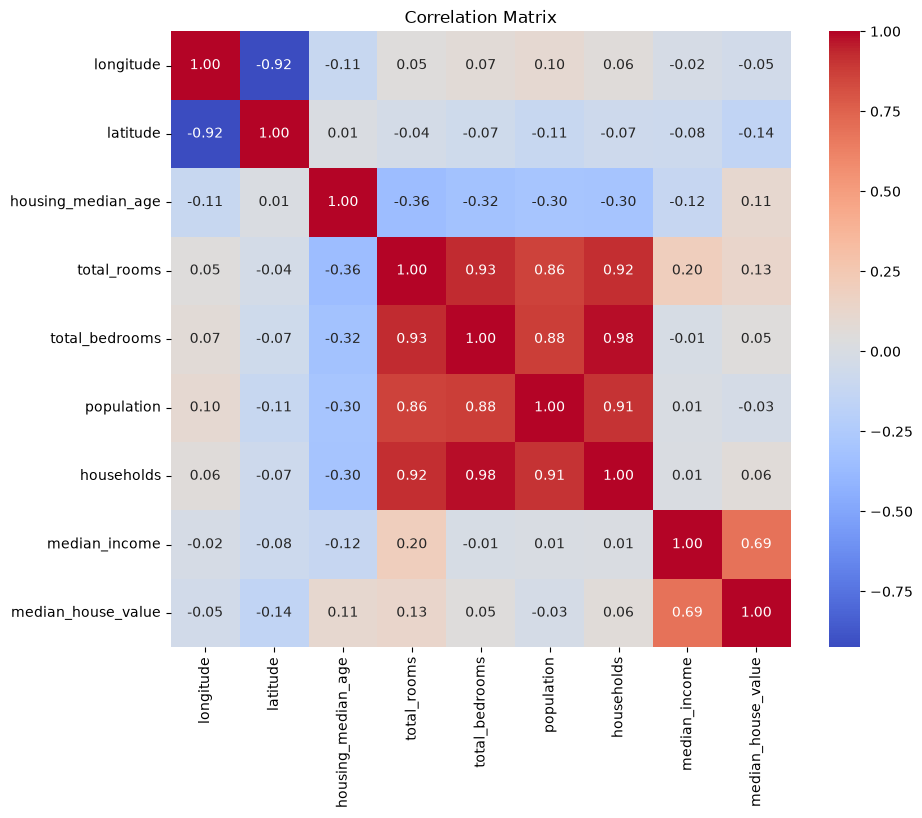

In [14]:
plt.figure(figsize=(10,8))

corr = df[numerical_columns].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

# ===========================================
# Histograms
# ===========================================

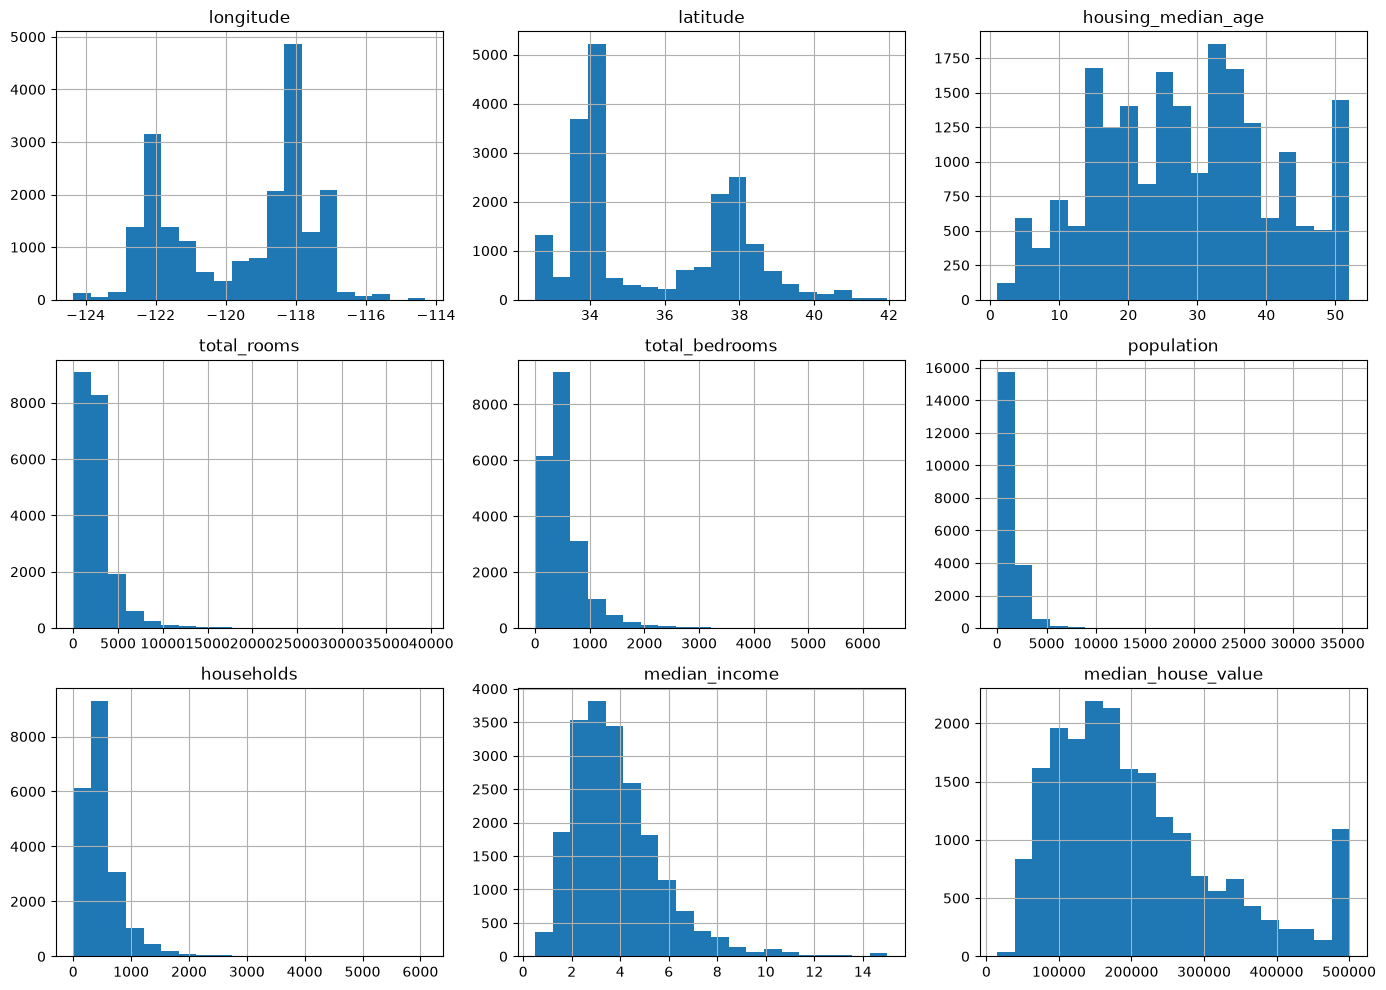

In [15]:
df[numerical_columns].hist(figsize=(14,10), bins=20)

plt.tight_layout()
plt.show()


# ===========================================
# Boxplots
# ===========================================

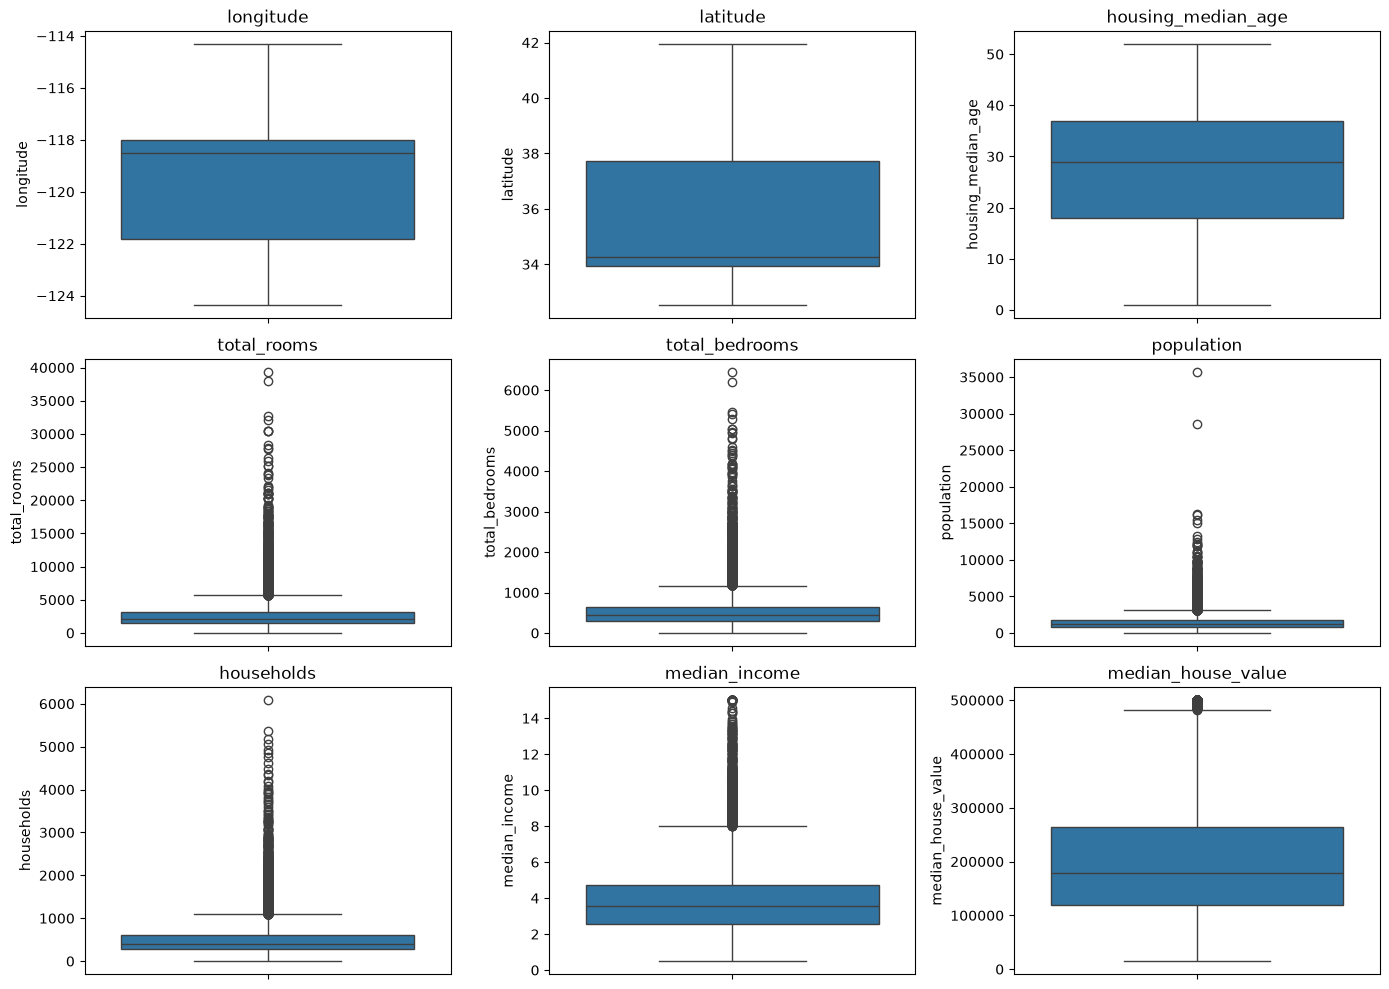

In [16]:
plt.figure(figsize=(14,10))

for i, col in enumerate(numerical_columns,1):

    plt.subplot(3,3,i)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()
plt.show()

# ===========================================
# Encode Categorical Variable
# ===========================================

In [17]:
print("\nEncoding ocean_proximity...")

df = pd.get_dummies(
    df,
    columns=["ocean_proximity"],
    drop_first=True
)

print(df.head())


Encoding ocean_proximity...
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41          880           129.0   
1    -122.22     37.86                  21         7099          1106.0   
2    -122.24     37.85                  52         1467           190.0   
3    -122.25     37.85                  52         1274           235.0   
4    -122.25     37.85                  52         1627           280.0   

   population  households  median_income  median_house_value  \
0         322         126         8.3252              452600   
1        2401        1138         8.3014              358500   
2         496         177         7.2574              352100   
3         558         219         5.6431              341300   
4         565         259         3.8462              342200   

   ocean_proximity_INLAND  ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  \
0                   False                   False       

# ===========================================
# Feature Selection
# ===========================================

In [18]:
X = df.drop("median_house_value", axis=1)

y = df["median_house_value"]


# ===========================================
# Train Test Split
# ===========================================

In [19]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42

)

# ===========================================
# Build Model
# ===========================================


In [20]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[-27108.75,-25657.81, 1081.36,...,213653.37, -6232.42, 3166.48]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['longitude','latitude','housing_median_age',...,'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY','ocean_proximity_NEAR OCEAN']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.299e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


# ===========================================
# Prediction
# ===========================================

In [21]:
y_pred = model.predict(X_test)

# ===========================================
# Evaluation
# ===========================================

In [22]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\nModel Performance")

print("MSE :", mse)

print("RMSE:", rmse)

print("R² Score :", r2)


Model Performance
MSE : 4802173538.604191
RMSE: 69297.71669113052
R² Score : 0.648840215443197


# ===========================================
# Feature Importance
# ===========================================

In [23]:
coefficients = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": model.coef_

})

In [24]:
coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

In [25]:
print("\nFeature Coefficients")

print(coefficients)


Feature Coefficients
                       Feature    Coefficient
9       ocean_proximity_ISLAND  213653.374463
7                median_income   39277.083020
8       ocean_proximity_INLAND  -39240.217778
0                    longitude  -27108.746321
1                     latitude  -25657.807543
10    ocean_proximity_NEAR BAY   -6232.416876
11  ocean_proximity_NEAR OCEAN    3166.477128
2           housing_median_age    1081.364206
4               total_bedrooms     103.004042
6                   households      43.142725
5                   population     -36.409751
3                  total_rooms      -6.322146


# ===========================================
# Actual vs Predicted
# ===========================================


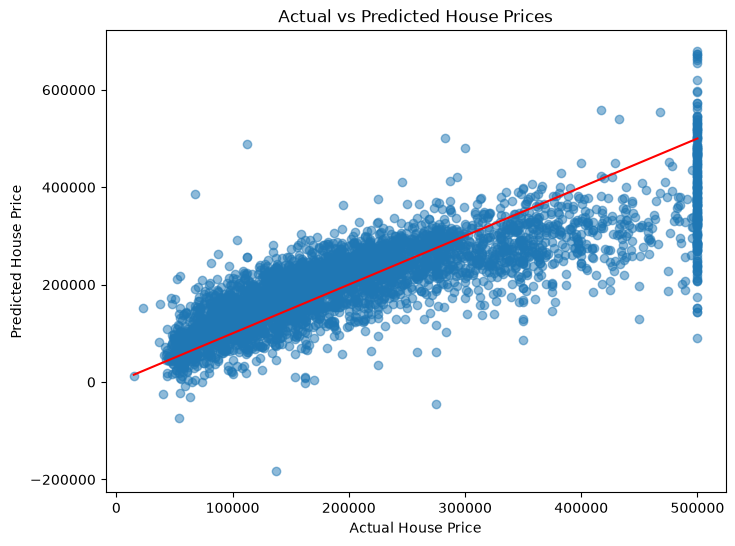

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual House Price")

plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

# ===========================================
# Predict New House
# ===========================================

In [29]:
new_house = pd.DataFrame({

    "longitude":[-122.23],
    "latitude":[37.88],
    "housing_median_age":[30],
    "total_rooms":[870],
    "total_bedrooms":[129],
    "population":[452],
    "households":[206],
    "median_income":[8.3252],

    "ocean_proximity_INLAND":[0],
    "ocean_proximity_ISLAND":[0],
    "ocean_proximity_NEAR BAY":[1],
    "ocean_proximity_NEAR OCEAN":[0]

})

In [30]:
prediction = model.predict(new_house)

print("\nPredicted House Price : $", prediction[0])

# ===========================================
# Save Model
# ===========================================

joblib.dump(model,"house_price_model.pkl")

print("\nModel Saved Successfully")


Predicted House Price : $ 395726.0803861525

Model Saved Successfully
